# Example: Optimising a site with a load and four EVs

This example shows how to model different kinds of EVs. How to model different EVs is explained later in this example.

### Imports

Import everything we need

In [126]:
import numpy as np
from echo.models.base import Node, OptimisationGraph
from echo.models.agnostic import FlexPort, TellegenNode
from echo.models.electrical import EV, ElectricalDemand
from echo.configuration import Units
from echo.objectives.tariff import ImportTariff, ExportTariff
from echo.objectives.base import ObjectiveSet
from echo.optimiser import optimise
from echo.models.scenario import EngineSettings, ScenarioSettings

### Defining the scenario

The first thing we need to do is define the time periods for the optimisation. Here we have 96 time periods each 15 minutes in length.

In [127]:
time_periods = 96  # total number of intervals
interval_duration = 15  # Duration in mins of each interval
expansion_periods = 1  # Number of planning intervals - in echo V1, set to 1 always

scenario_settings = ScenarioSettings(
    interval_duration=interval_duration,
    number_of_intervals=time_periods,
    number_of_expansion_intervals=expansion_periods,
    discount_rate=0,
)

### Defining the load data

Load data can be defined with a list or alternatively a numpy array.

*Note:* The number of elements in the `load_array` should be match the number of time periods i.e. `96`.



In [128]:
load_array = np.array(
    [2.13, 2.09, 2.3, 2.11, 2.2, 2.23, 15, 15, 15, 2.19, 2.19, 2.19, 2.12, 2.15, 2.25, 2.12, 2.21, 2.16,
     2.26, 2.13, 2.08, 2.15, 2.42, 2.02, 2.3, 2.26, 2.35, 2.55, 3.23, 2.98, 3.49, 3.5, 3.12, 3.52, 3.94, 3.55,
     3.99, 3.71, 3.38, 3.76, 3.71, 3.78, 3.29, 3.65, 3.61, 3.75, 3.38, 3.66, 3.56, 3.69, 3.3, 3.61, 3.71, 3.82,
     3.17, 3.69, 3.74, 3.86, 3.57, 3.55, 3.75, 3.6, 3.67, 3.48, 3.51, 3.46, 3.19, 3.38, 3.19, 3.38, 3.04, 3.12,
     2.91, 3.11, 3.13, 2.77, 2.24, 2.54, 2.24, 2.24, 2.09, 2.33, 2.17, 2.16, 1.97, 2.16, 2.21, 2.18, 2.01, 2.16,
     2.19, 2.11, 2.17, 2.13, 12, 12])

### Creating the network

Create the nodes (grid, CP, solar, load, battery) and the ports which will connect them.

First we create a node representing upstream grid.

In [129]:
grid = Node(node_name="grid")
grid.add_port("grid", FlexPort(units=Units.KW))

Create the connection point

In [130]:
connection_point = TellegenNode(node_name="CP")
connection_point.add_ports_from_list(['grid', 'load', 'ev_v0g', 'ev_v1g', 'ev_v2g', 'ev_tod'], FlexPort, units=Units.KW)  # add ports with easily referenced names

Here we are creating a node to represent the load. Load nodes typically have a single port.

In [131]:
load = Node(node_name="load")
load_port = ElectricalDemand()
load_port.add_demand_profile_from_array(load_array, expansion_periods)
load.ports['load'] = load_port

Next we create nodes to represent the three different EVs.

EV nodes have similar parameters to a battery.

The additional parameters of note are `soc_conserv`, `soc_conserv_cost`, `tod_charging`, and `trip_slack`. See comments below for more details on these parameters.

#### v0g EV
A `v0g` vehicle 'convenience' charges (charges at max capacity until full) when it is plugged in to the grid.

In [132]:
v0g_availability = [1] * 48 + [0] * 48  # binary array, 1 indicates it is plugged in and can charge
v0g_trip_usage = [0] * 48 + [0.5] * 48  # in average kW per interval

v0g = EV(
    node_name="v0g",
    charge_mode="V0G",
    available=v0g_availability,
    usage=v0g_trip_usage,
    connection_port_name="cp",
    max_capacity=40,
    depth_of_discharge_limit=0,
    charging_power_limit=10,
    discharging_power_limit=-1e4,
    charging_efficiency=1,
    discharging_efficiency=1,
    initial_state_of_charge=20,
    soc_conserv=None,  # Set to some state of charge (in kWh) to apply a conservative state of charge constraint, where the battery will not discharge below the soc_conserv value when plugged in to the grid.
    soc_conserv_cost=0.0,  # A cost on violating the soc_conserv level.
    interval_duration=interval_duration,
    tod_charging=None,  # Set to an array like 'available' to represent when the vehicle can charge
    trip_slack=True, # Should be set to True by default. Introduces a slack variable on the battery soc to allow it to 'complete' infeasible trips
)  

#### v0g Time-of-day EV

Next we define a variant of V0G that has restrictions on when it can charge, which is controlled through the `tod_charging` attribute.

For `v0g_tod` we prevent charging for the first 24 time periods (of the full 96 time period simulation)

In [133]:
v0g_tod_availability = v0g_availability
v0g_tod_trip_usage = v0g_tod_trip_usage

tod_charging = np.ones(np.array(v0g_tod_availability).shape)
tod_charging[0:24] = 0.0  # Disallow charging during some time periods by setting to 0

v0g_tod = EV(
    node_name="v0g-tod",
    charge_mode="V0G",
    available=v0g_tod_availability,
    usage=v0g_tod_trip_usage,
    connection_port_name="cp",
    max_capacity=40,
    depth_of_discharge_limit=0,
    charging_power_limit=10,
    discharging_power_limit=-1e4,
    charging_efficiency=1,
    discharging_efficiency=1,
    initial_state_of_charge=20,
    soc_conserv=None,  # Set to some state of charge (in kWh) to apply a conservative state of charge constraint, where the battery will not discharge below the soc_conserv value when plugged in to the grid.
    soc_conserv_cost=0.0,  # A cost on violating the soc_conserv level.
    interval_duration=interval_duration,
    tod_charging=tod_charging,  # Set to an array like 'available' to represent when the vehicle can charge
    trip_slack=True,  # Should be set to True by default. Introduces a slack variable on the battery soc to allow it to 'complete' infeasible trips
)

#### v1g EV

`v1g` can only charge from the grid, but when it charges is flexible and can be optimised.

In [134]:
v1g_availability = [1] * 48 + [0] * 48  # binary array, 1 indicates it is plugged in and can charge
v1g_trip_usage = [0] * 48 + [2] * 48  # in average kW per interval

v1g = EV(
    node_name="v1g",
    charge_mode="V1G",
    available=v1g_availability,
    usage=v1g_trip_usage,
    connection_port_name="cp",
    max_capacity=40,
    depth_of_discharge_limit=0.0,
    charging_power_limit=10.0,
    discharging_power_limit=-10.0,
    charging_efficiency=1.0,
    discharging_efficiency=1.0,
    initial_state_of_charge=0.0,
    tod_charging=None,
    soc_conserv=None,
    soc_conserv_cost=0.0,
    trip_slack=True,
    interval_duration=interval_duration,
)

#### v2g EV

A `v2g` vehicle can charge from and discharge to the grid.
Here, we set the total trip consumption (60 kWh) to be greater than the capacity of the battery (40kWh) to demonstrate the `trip_slack` variable.

In [135]:
v2g_availability = [1] * 48 + [0] * 48  # binary array, 1 indicates it is plugged in and can charge
v2g_trip_usage = [0] * 48 + [5] * 48  # in average kW per interval

v2g = EV(
    node_name="v2g",
    charge_mode="V2G",
    available=v2g_availability,
    usage=v2g_trip_usage,
    connection_port_name="cp",
    max_capacity=40,
    depth_of_discharge_limit=0.0,
    charging_power_limit=10.0,
    discharging_power_limit=-10.0,
    charging_efficiency=1.0,
    discharging_efficiency=1.0,
    initial_state_of_charge=0.0,
    tod_charging=None,
    soc_conserv=None,
    soc_conserv_cost=0.0,
    trip_slack=True,
    interval_duration=interval_duration,
)

Create the graph(network) by adding the nodes and joining the nodes via their ports.

In [136]:
network = OptimisationGraph()

network.add_nodes_from([grid, connection_point, load, v0g, v1g, v2g, v0g_tod])  # nodes can be added one by one or as a list

network.connect_ports_and_create_edge(grid.ports['grid'], connection_point.ports['grid'])
network.connect_ports_and_create_edge(connection_point.ports['load'], load.ports['load'])
network.connect_ports_and_create_edge(connection_point.ports['ev_v0g'], v0g.ports['cp'])
network.connect_ports_and_create_edge(connection_point.ports['ev_v1g'], v1g.ports['cp'])
network.connect_ports_and_create_edge(connection_point.ports['ev_v2g'], v2g.ports['cp'])
network.connect_ports_and_create_edge(connection_point.ports['ev_tod'], v0g_tod.ports['cp'])


We can visualise our BTM site as a matplotlib figure. The labels are obtained from the `node_name`s. We also add some styling (through the `style` dictionary) to improve the visual appearance.

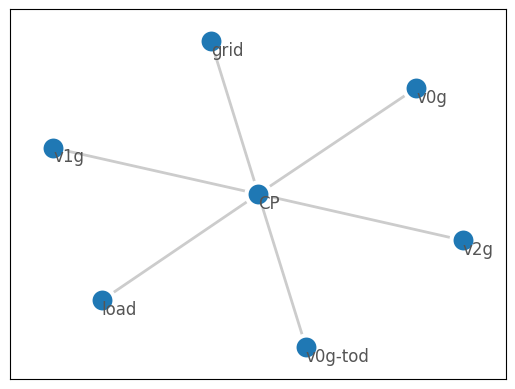

In [137]:
import matplotlib.pyplot as plt

network_figure = plt.figure()
network_axes = network_figure.add_subplot()
style = {
    "edgecolors": "#FFFFFF", # node border color
    "linewidths": 3, # node border width
    "edge_color": "#CCCCCC", # edge color of edges
    "width": 2, # edge width
    "horizontalalignment": "left", # label horizontal position
    "verticalalignment": "top", # label vertical position
    "font_color": "#555555", # label text color
}
network.draw_on_axes(axes=network_axes, with_labels=True, **style)
plt.show()

### Create objectives

Here we will create an import tariff and export tariff.

In [138]:
# Tariffs are in $ / kWh
import_tariff_array = np.array(([0.1] * 28 + [0.3] * 8 + [0.2] * 32 + [0.3] * 16 + [0.1] * 12))
export_tariff_array = np.array(([0.0] * 96))

# First create the tariffs as echo objects
import_cost = ImportTariff(component=connection_point.ports['grid'],
                           tariff_array=import_tariff_array,
                           expansion_periods=expansion_periods)  # create the import objective cost

export_cost = ExportTariff(component=connection_point.ports['grid'],
                           tariff_array=export_tariff_array,
                           expansion_periods=expansion_periods)  # create the export objective cost

We then add these two objectives to an objective set.

In [139]:
# define the objective set, which is just a list with the two costs
objective_set = ObjectiveSet(objective_list=[import_cost, export_cost])

### Setup and run the optimiser

Here we are going to use [cplex](https://www.ibm.com/products/ilog-cplex-optimization-studio/cplex-optimizer) solver.

In [140]:
engine_settings = EngineSettings(
    engine="cplex",
    engine_executable="",
    bigM=5000000,  # This value has been arbitrarily chosen
    smallM=0.0001,  # This value has been arbitrarily chosen
)

Perform the optimisation passing in all the required information (solver, scenario, network and objectives)

In [141]:
optimise_results = optimise(
    scenario_settings=scenario_settings,
    engine_settings=engine_settings,
    graph=network,
    objective_set=objective_set,
)

/home/mike/Documents/Projects/echo/src/echo/models/base.py:1106: UserWarning: Ports {'port_LoJhCizppEPr28rVpLkEyq', 'port_5nCjDFaHpZhAFZD9dcvKra', 'port_FvpTnf7WUDemgg6h3vwLZC', 'port_8ykK2VR7oRm3Zfk4WVe9RT', 'port_7sGBmyxjdrb5pgsK4ei45X', 'port_DB6WazaDqi59X9ao2u75fv', 'port_FiuzcYjciCDsRKVcMKcN2g', 'port_BzBDMpk7XtKMsXZevx5YqJ'} are defined on nodes but are not part of an edge. This may cause erroneous optimisation results.
  warnings.warn(



Welcome to IBM(R) ILOG(R) CPLEX(R) Interactive Optimizer 22.1.1.0
  with Simplex, Mixed Integer & Barrier Optimizers
5725-A06 5725-A29 5724-Y48 5724-Y49 5724-Y54 5724-Y55 5655-Y21
Copyright IBM Corp. 1988, 2022.  All Rights Reserved.

Type 'help' for a list of available commands.
Type 'help' followed by a command name for more
information on commands.

CPLEX> Logfile 'cplex.log' closed.
Logfile '/tmp/tmpkkh_hwcf.cplex.log' open.
CPLEX> Problem '/tmp/tmp34_zjy34.pyomo.lp' read.
Read time = 0.01 sec. (0.23 ticks)
CPLEX> Problem name         : /tmp/tmp34_zjy34.pyomo.lp
Objective sense      : Minimize
Variables            :    2496  [Nneg: 480,  Box: 768,  Free: 1056,
                                 Binary: 96,  Other: 96]
Objective nonzeros   :     480
Linear constraints   :    2496  [Less: 576,  Greater: 384,  Equal: 1536]
  Nonzeros           :    5372
  RHS nonzeros       :     770

Variables            : Min LB: -10000.00        Max UB: 40.00000       
Objective nonzeros   : Min   :

### Extract optimised results

These are retrieved by calling the optimiser .values() method, and providing the variable name we want.

For each of the EVs we extract:

- the battery power (accessed using `port_name` of the vehicle port)
- the state of charge (accessed through `soc_value`)


We are also interested in the optimised load at the connection to the grid from the CP

In [142]:
v0g_delta = optimise_results.values(v0g.ports['vehicle'].port_name, 0)
v0g_soc = optimise_results.values(v0g.ports['vehicle'].soc_value, 0)

v0g_tod_delta = optimise_results.values(v0g_tod.ports['vehicle'].port_name, 0)
v0g_tod_soc = optimise_results.values(v0g_tod.ports['vehicle'].soc_value, 0)


v1g_delta = optimise_results.values(v1g.ports['vehicle'].port_name, 0)
v1g_soc = optimise_results.values(v1g.ports['vehicle'].soc_value, 0)

v2g_delta = optimise_results.values(v2g.ports['vehicle'].port_name, 0)
v2g_soc = optimise_results.values(v2g.ports['vehicle'].soc_value, 0)
v2g_slack = optimise_results.values(v2g.ports['vehicle'].trip_slack)

optimised_connection_point_load = optimise_results.values(connection_point.ports['grid'].port_name, 0)

### Analyse the results

Create a figure with six plots.

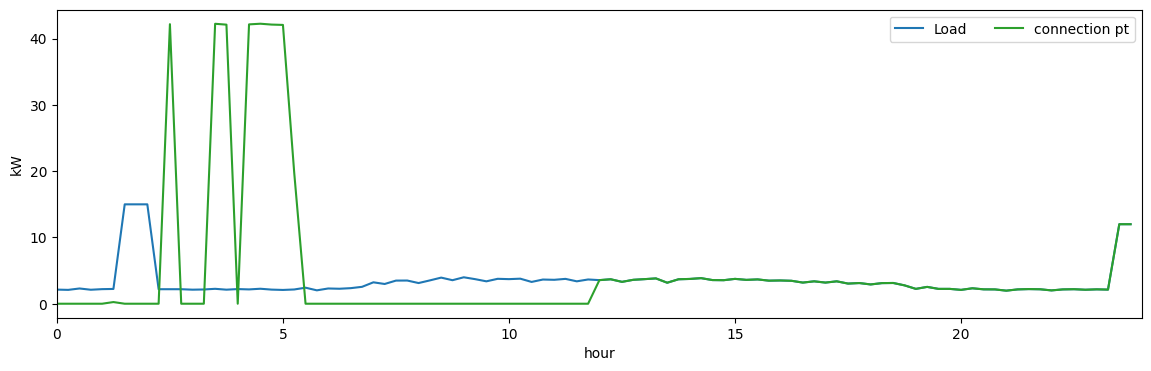

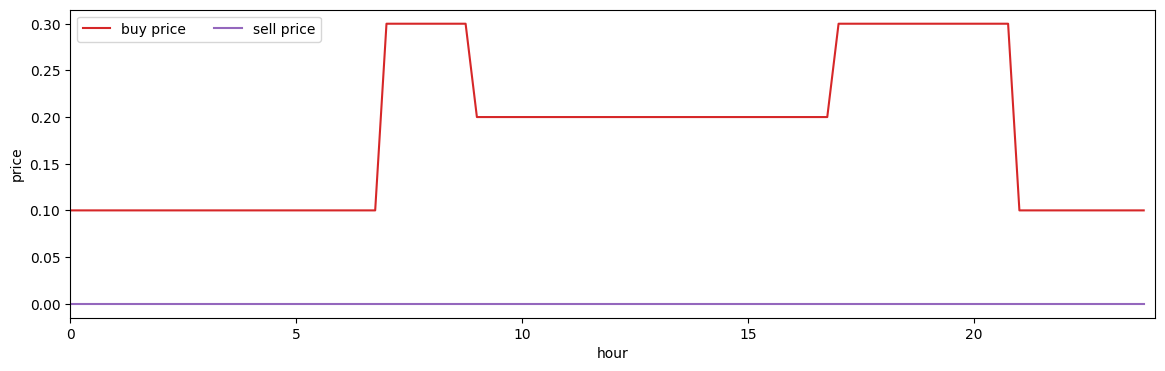

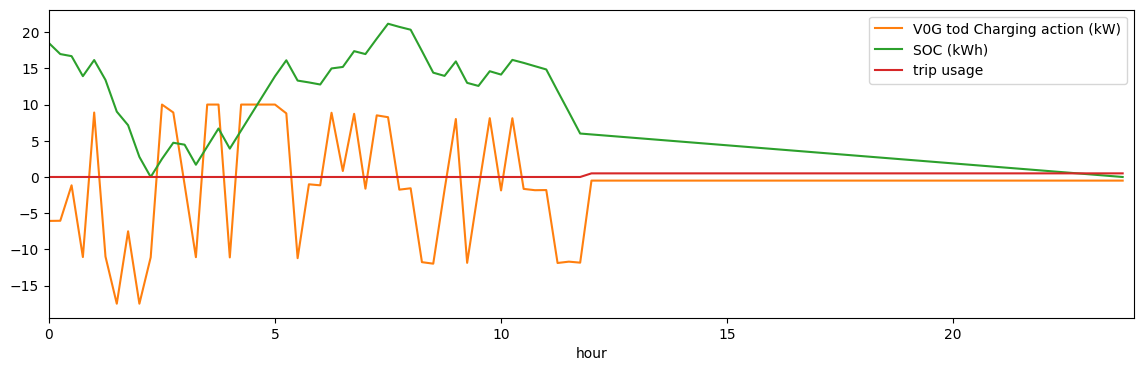

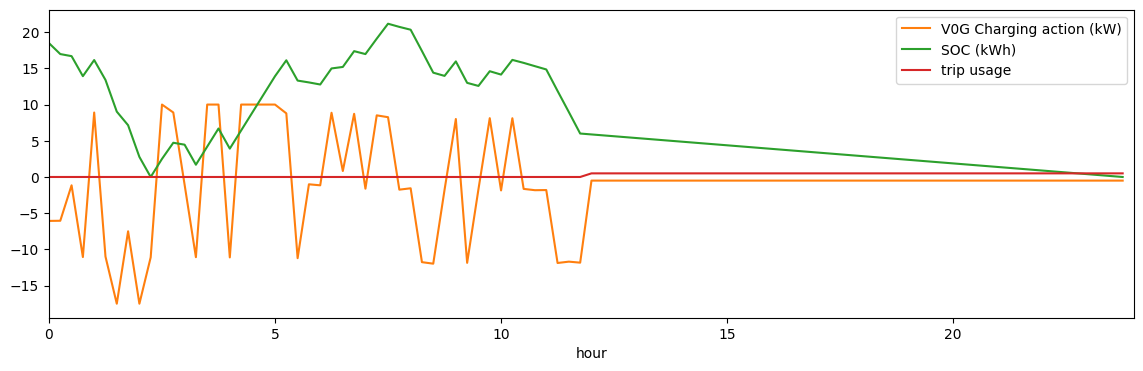

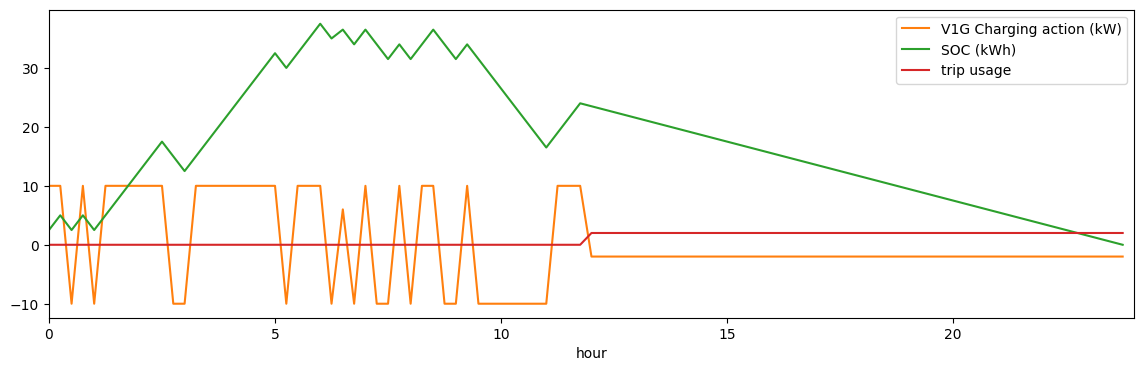

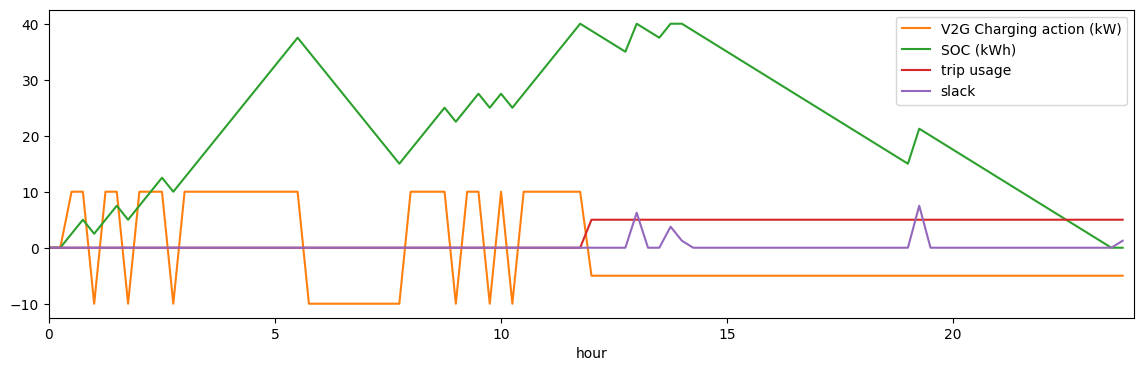

In [143]:
import matplotlib.pyplot as plt
import seaborn as sns

colors = sns.color_palette()
hrs = np.arange(0, len(load_array)) / 4
fig = plt.figure(figsize=(14, 4))
ax1 = fig.add_subplot(1, 1, 1)
line1, = ax1.plot(hrs, load_array, color=colors[0])
line3, = ax1.plot(hrs, optimised_connection_point_load, color=colors[2])
ax1.set_xlabel('hour'), ax1.set_ylabel('kW')
ax1.legend([line1, line3], ['Load', 'connection pt'], ncol=2)
ax1.set_xlim([0, len(load_array) / 4])

fig = plt.figure(figsize=(14, 4))
ax2 = fig.add_subplot(1, 1, 1)
line1, = ax2.plot(hrs, import_tariff_array, color=colors[3])
line2, = ax2.plot(hrs, export_tariff_array, color=colors[4])
ax2.set_xlabel('hour'), ax2.set_ylabel('price')
ax2.legend([line1, line2], ['buy price', 'sell price'], ncol=2)
ax2.set_xlim([0, len(load_array) / 4])

fig = plt.figure(figsize=(14, 4))
ax3 = fig.add_subplot(1, 1, 1)
line1, = ax3.plot(hrs, v0g_tod_delta, color=colors[1])
line2, = ax3.plot(hrs, v0g_tod_soc, color=colors[2])
line3, = ax3.plot(hrs, v0g_tod_trip_usage, color=colors[3])
ax3.set_xlim([0, len(load_array) / 4])
ax3.set_xlabel('hour')
ax3.legend([line1, line2, line3], ['V0G tod Charging action (kW)', 'SOC (kWh)', 'trip usage'])
plt.show()

fig = plt.figure(figsize=(14, 4))
ax3 = fig.add_subplot(1, 1, 1)
line1, = ax3.plot(hrs, v0g_delta, color=colors[1])
line2, = ax3.plot(hrs, v0g_soc, color=colors[2])
line3, = ax3.plot(hrs, v0g_trip_usage, color=colors[3])
ax3.set_xlim([0, len(load_array) / 4])
ax3.set_xlabel('hour')
ax3.legend([line1, line2, line3], ['V0G Charging action (kW)', 'SOC (kWh)', 'trip usage'])
plt.show()

fig = plt.figure(figsize=(14, 4))
ax4 = fig.add_subplot(1, 1, 1)
line1, = ax4.plot(hrs, v1g_delta, color=colors[1])
line2, = ax4.plot(hrs, v1g_soc, color=colors[2])
line3, = ax4.plot(hrs, v1g_trip_usage, color=colors[3])
ax4.set_xlim([0, len(load_array) / 4])
ax4.set_xlabel('hour')
ax4.legend([line1, line2, line3], ['V1G Charging action (kW)', 'SOC (kWh)', 'trip usage'])
plt.show()

fig = plt.figure(figsize=(14, 4))
ax5 = fig.add_subplot(1, 1, 1)
line1, = ax5.plot(hrs, v2g_delta, color=colors[1])
line2, = ax5.plot(hrs, v2g_soc, color=colors[2])
line3, = ax5.plot(hrs, v2g_trip_usage, color=colors[3])
line4, = ax5.plot(hrs, v2g_slack, color=colors[4])
ax5.set_xlim([0, len(load_array) / 4])
ax5.set_xlabel('hour')
ax5.legend([line1, line2, line3, line4], ['V2G Charging action (kW)', 'SOC (kWh)', 'trip usage', 'slack'])
plt.show()